**Setup & Dataset Loading:**



In [ ]:
!pip install -q ultralytics
import glob, math, random, yaml, os, cv2
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from google.colab import drive
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

print("GPU:", torch.cuda.is_available())
drive.mount("/content/drive")
os.makedirs("/content/drive/MyDrive/hexovate", exist_ok=True)

info = check_det_dataset("VisDrone.yaml")        # downloads and converts if missing
root = str(info["path"])
names = ["pedestrian","people","bicycle","car","van","truck","tricycle","awning-tricycle","bus","motor"]

# oversampling (same settings as before: seed 0, t=0.5, cap 4)
random.seed(0)
img_classes = {}
for lf in sorted(glob.glob(f"{root}/labels/train/*.txt")):      # sorted = same order every time
    img = lf.replace("/labels/", "/images/").replace(".txt", ".jpg")
    img_classes[img] = {int(l.split()[0]) for l in open(lf)}
N = len(img_classes)
freq = {c: sum(c in s for s in img_classes.values()) / N for c in range(10)}
rep = {c: min(4.0, max(1.0, math.sqrt(0.5 / f))) for c, f in freq.items()}
lines = []
for img, cs in img_classes.items():
    r = max(rep[c] for c in cs) if cs else 1.0
    n = int(r) + (random.random() < r - int(r))
    lines += [img] * max(1, n)
open("/content/train_oversampled.txt", "w").write("\n".join(lines))
yaml.dump({"path": root, "train": "/content/train_oversampled.txt",
           "val": "images/val", "names": dict(enumerate(names))},
          open("/content/visdrone_os.yaml", "w"), sort_keys=False)
print(f"Train images: {N} -> {len(lines)}")

# keep copies on Drive so a restart can't wipe them
!cp /content/visdrone_os.yaml /content/train_oversampled.txt /content/drive/MyDrive/hexovate/
print("Setup done")

GPU: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train images: 6471 -> 8138
Setup done


**Exploratory Data Analysis (class counts, object sizes):**

train 6471 images, 6471 label files
val 548 images, 548 label files
test 1610 images, 1610 label files
Class ids found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


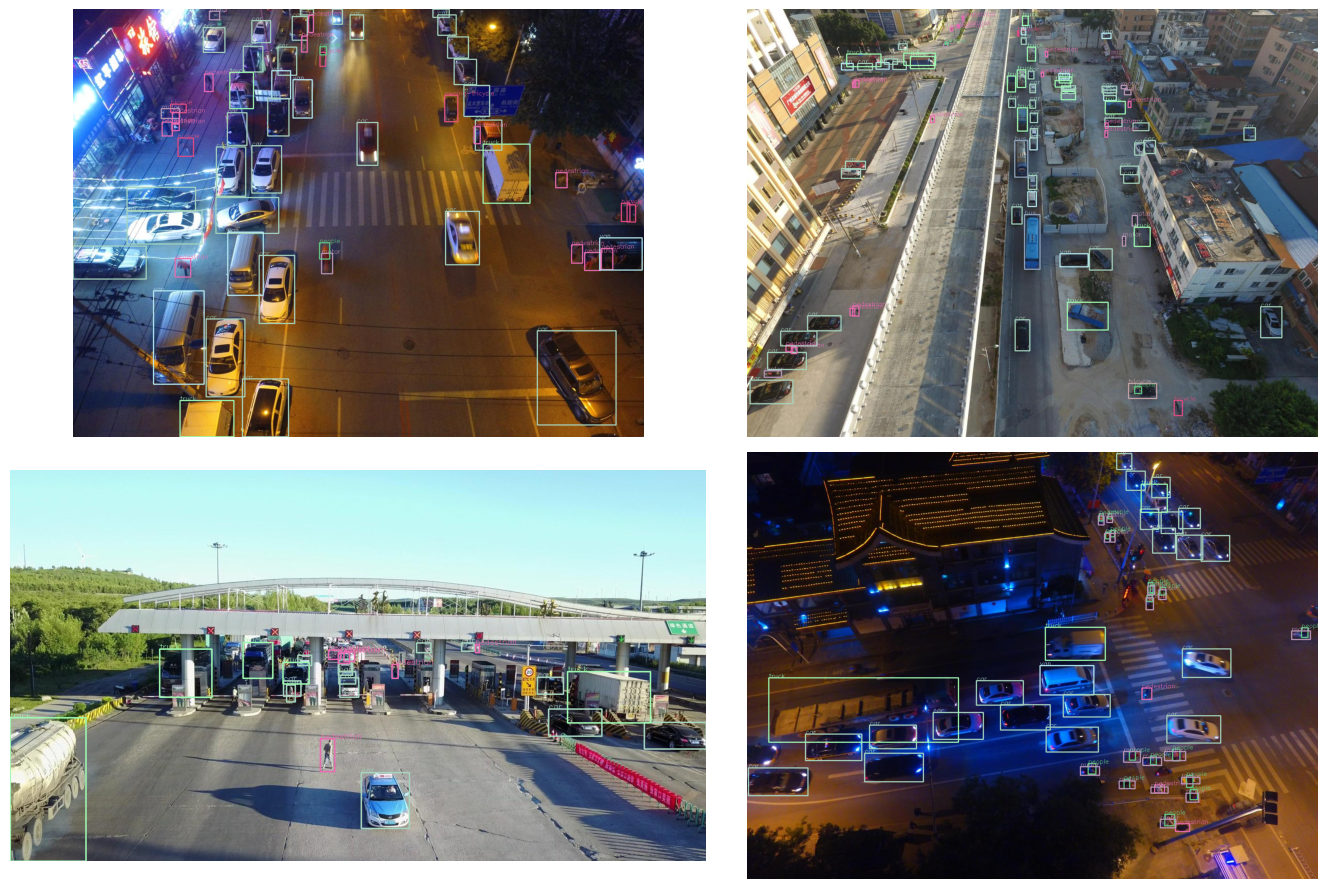

In [ ]:
import glob, os, cv2, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

root = "/content/datasets/VisDrone"
names = ["pedestrian","people","bicycle","car","van","truck","tricycle","awning-tricycle","bus","motor"]

# 2a. counts per split
for s in ["train", "val", "test"]:
    print(s, len(glob.glob(f"{root}/images/{s}/*.jpg")), "images,",
          len(glob.glob(f"{root}/labels/{s}/*.txt")), "label files")

# 2b. make sure only classes 0-9 exist (ignored regions must not appear)
all_cls = set()
for f in glob.glob(f"{root}/labels/train/*.txt"):
    all_cls |= {int(l.split()[0]) for l in open(f)}
print("Class ids found:", sorted(all_cls))   # expect 0..9

# 2c. draw a few images with their boxes
colors = [tuple(int(x) for x in np.random.RandomState(i).randint(60, 255, 3)) for i in range(10)]

def draw(img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    lbl = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    if os.path.exists(lbl):
        for line in open(lbl):
            c, x, y, w, h = line.split(); c = int(c)
            x, y, w, h = float(x)*W, float(y)*H, float(w)*W, float(h)*H
            p1, p2 = (int(x-w/2), int(y-h/2)), (int(x+w/2), int(y+h/2))
            cv2.rectangle(img, p1, p2, colors[c], 2)
            cv2.putText(img, names[c], p1, cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[c], 1)
    return img

samples = random.sample(glob.glob(f"{root}/images/train/*.jpg"), 4)
fig, axs = plt.subplots(2, 2, figsize=(14, 9))
for ax, p in zip(axs.ravel(), samples):
    ax.imshow(draw(p)); ax.axis("off")
plt.tight_layout(); plt.show()

class
pedestrian          79337
people              27059
bicycle             10480
car                144867
van                 24956
truck               12875
tricycle             4812
awning-tricycle      3246
bus                  5926
motor               29647
Name: count, dtype: int64
Imbalance ratio (max/min): 44.6


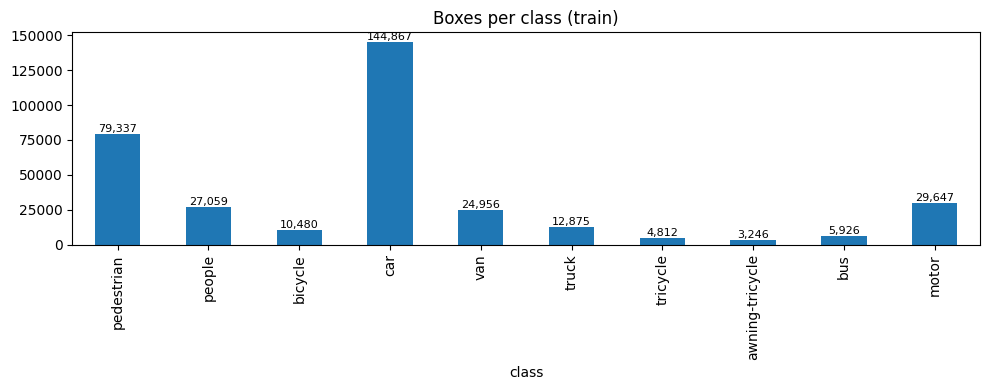

count    343205.0
mean         15.3
std          13.7
min           0.0
25%           6.6
50%          11.1
75%          18.8
max         264.2
Name: side640, dtype: float64

Share of boxes by size at 640 px:
bucket
<8px       0.333
8-16px     0.350
16-32px    0.223
>32px      0.095
Name: proportion, dtype: float64

Median object side (px at 640) per class:
class
pedestrian          7.8
people              7.1
bicycle             9.8
car                14.0
van                15.3
truck              19.8
tricycle           14.7
awning-tricycle    14.7
bus                21.6
motor               9.7
Name: side640, dtype: float64


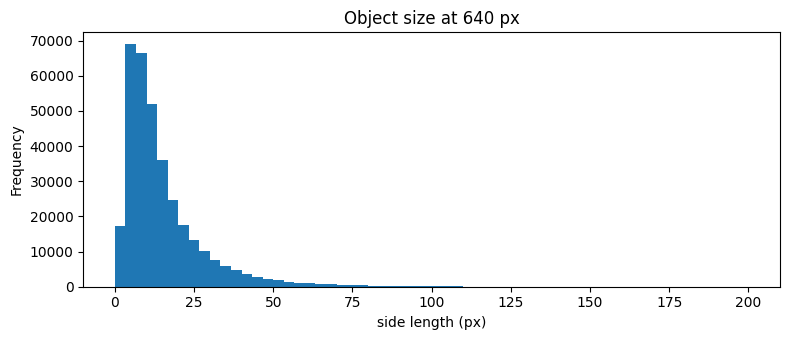

In [ ]:
from PIL import Image

rows = []
for lf in glob.glob(f"{root}/labels/train/*.txt"):
    img = lf.replace("/labels/", "/images/").replace(".txt", ".jpg")
    W, H = Image.open(img).size
    scale = 640 / max(W, H)                       # size after resize to imgsz=640
    for line in open(lf):
        c, x, y, w, h = line.split()
        w, h = float(w)*W, float(h)*H
        rows.append((os.path.basename(lf), int(c), w, h, w*scale, h*scale))

df = pd.DataFrame(rows, columns=["img", "cls", "w_px", "h_px", "w640", "h640"])
df["class"] = df.cls.map(dict(enumerate(names)))
df["side640"] = np.sqrt(df.w640 * df.h640)       # object "side length" at 640 px
df["bucket"] = pd.cut(df.side640, [0, 8, 16, 32, 1e9], labels=["<8px", "8-16px", "16-32px", ">32px"])
df.to_csv("/content/train_boxes.csv", index=False)

# 3a. boxes per class + imbalance ratio
counts = df["class"].value_counts().reindex(names)
print(counts)
print("Imbalance ratio (max/min):", round(counts.max() / counts.min(), 1))

ax = counts.plot(kind="bar", figsize=(10, 4), title="Boxes per class (train)")
for i, v in enumerate(counts): ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig("/content/class_distribution.png", dpi=150); plt.show()

# 3b. object size stats
print(df.side640.describe().round(1))
print("\nShare of boxes by size at 640 px:")
print(df.bucket.value_counts(normalize=True).sort_index().round(3))
print("\nMedian object side (px at 640) per class:")
print(df.groupby("class").side640.median().reindex(names).round(1))

# 3c. size histogram
df.side640.clip(upper=200).plot(kind="hist", bins=60, figsize=(8, 3.5), title="Object size at 640 px")
plt.xlabel("side length (px)"); plt.tight_layout(); plt.savefig("/content/size_hist.png", dpi=150); plt.show()

**Baseline Training:**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data="VisDrone.yaml", epochs=15, imgsz=640, batch=16,
    seed=0, deterministic=True, workers=2,
    project="/content/runs", name="baseline",
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, over

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783858637590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
model = YOLO("yolo11n.pt")
model.train(
    data="/content/visdrone_os.yaml", epochs=15, imgsz=640, batch=16,
    seed=0, deterministic=True, workers=2,
    project="/content/runs", name="oversampled",
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone_os.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=oversampled, nbs=64, nms=None, opset=None, optimize=False, optim

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783841bd0280>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

**OverSampling:**

In [ ]:
import pandas as pd
from ultralytics import YOLO

def evaluate(weights, data="VisDrone.yaml", imgsz=640, name="val"):
    m = YOLO(weights)
    r = m.val(data=data, imgsz=imgsz, split="val", project="/content/runs", name=name, plots=True)
    per_class = pd.DataFrame({
        "class": [m.names[i] for i in r.box.ap_class_index],
        "AP50": r.box.ap50.round(3),
        "AP50-95": r.box.ap.round(3),
    })
    print(f"Overall  mAP50={r.box.map50:.3f}  mAP50-95={r.box.map:.3f}")
    return r.box.map50, r.box.map, per_class

# Baseline (Step 5) - needed because b50, b5095, base_pc are also undefined
b50, b5095, base_pc = evaluate("/content/runs/baseline/weights/best.pt", name="baseline_val")

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3472.8±826.5 MB/s, size: 163.8 KB)
val: Scanning /content/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 99.9Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 3.1it/s 11.4s
                   all        548      38759      0.366      0.297      0.253      0.142
            pedestrian        520       8844      0.362      0.329      0.265      

**Error Analysis:**

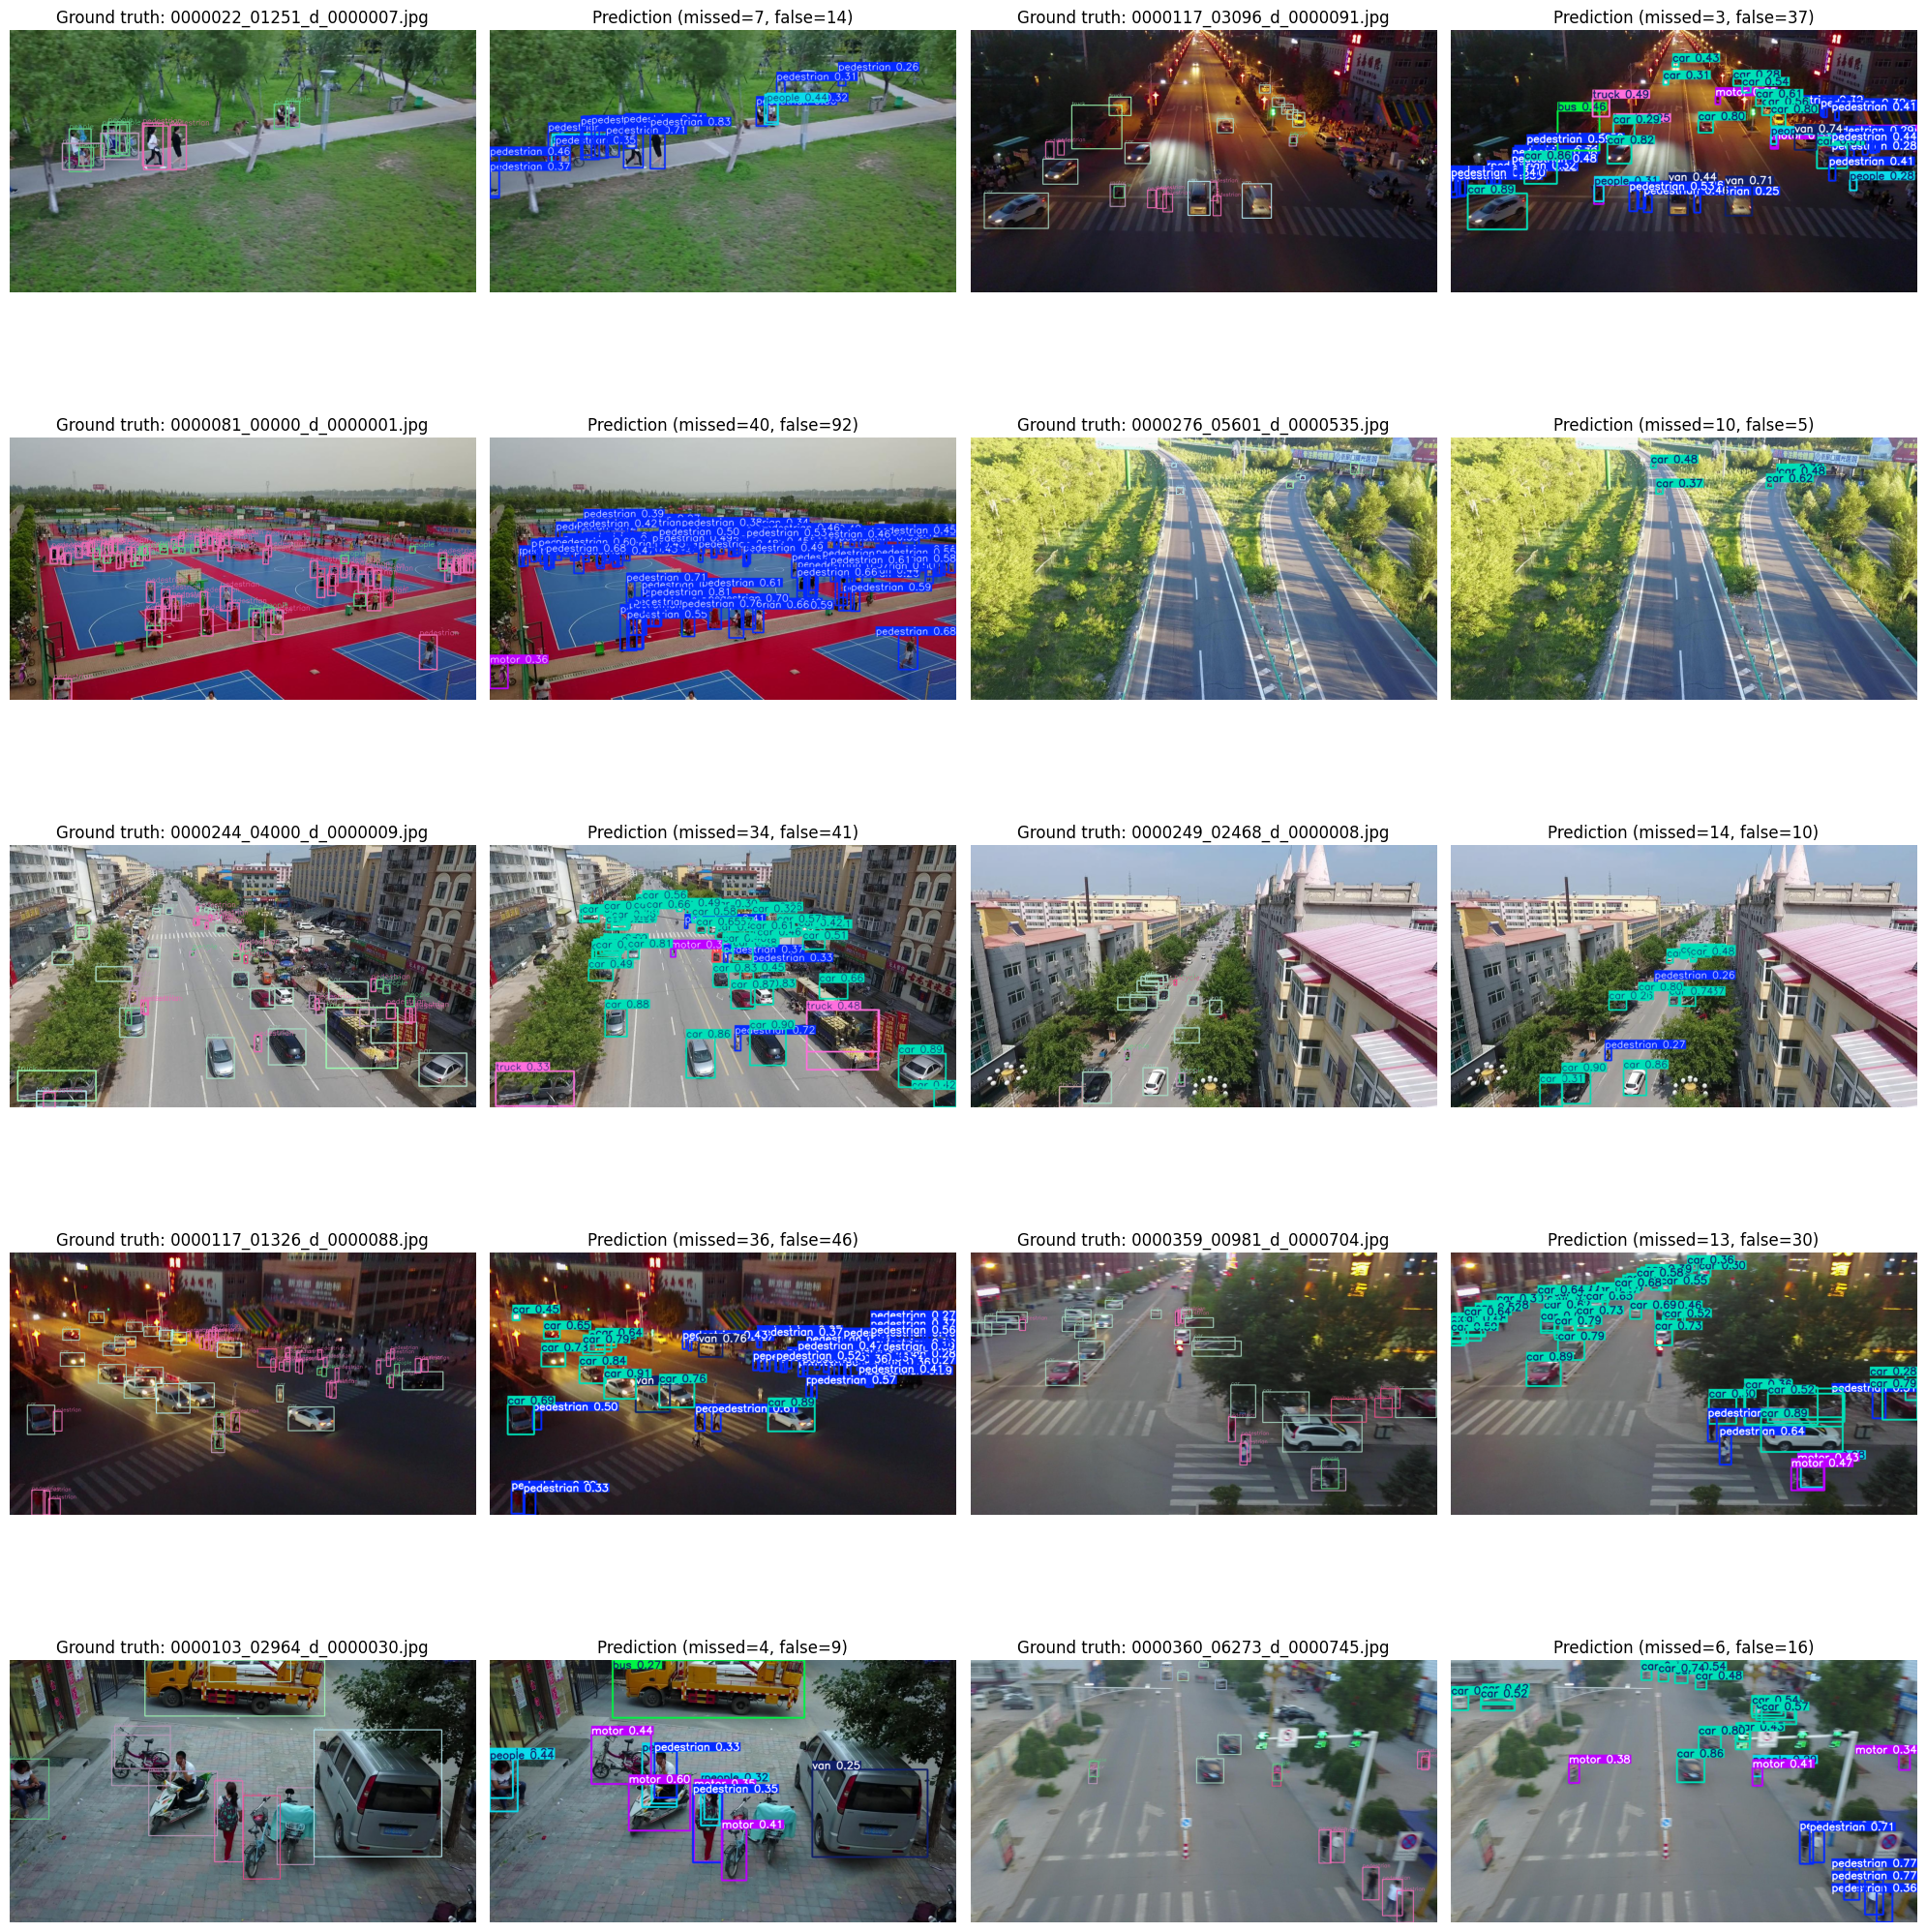

In [ ]:
from ultralytics.utils.metrics import box_iou
import torch

best = YOLO("/content/runs/oversampled/weights/best.pt")
val_imgs = sorted(glob.glob(f"{root}/images/val/*.jpg"))

def gt_of(p):
    img = cv2.imread(p); H, W = img.shape[:2]
    lbl = p.replace("/images/", "/labels/").replace(".jpg", ".txt")
    boxes, cls = [], []
    if os.path.exists(lbl):
        for l in open(lbl):
            c, x, y, w, h = l.split(); x, y, w, h = float(x)*W, float(y)*H, float(w)*W, float(h)*H
            boxes.append([x-w/2, y-h/2, x+w/2, y+h/2]); cls.append(int(c))
    return torch.tensor(boxes).reshape(-1, 4), torch.tensor(cls)

results = []
for p in val_imgs:
    gb, gc = gt_of(p)
    if len(gc) < 5: continue
    r = best.predict(p, imgsz=640, conf=0.25, max_det=1000, verbose=False)[0]
    pb, pc = r.boxes.xyxy.cpu(), r.boxes.cls.cpu().long()
    if len(pb):
        iou = box_iou(gb, pb)
        match = (iou > 0.5) & (gc[:, None] == pc[None, :])
        fn, fp = int((~match.any(1)).sum()), int((~match.any(0)).sum())
    else:
        fn, fp = len(gc), 0
    results.append((p, fn, fp, (fn + fp) / len(gc)))

worst = sorted(results, key=lambda x: -x[3])[:10]
fig, axs = plt.subplots(5, 4, figsize=(20, 22))
for i, (p, fn, fp, _) in enumerate(worst):
    r = best.predict(p, imgsz=640, conf=0.25, max_det=1000, verbose=False)[0]
    axs[i // 2][(i % 2) * 2].imshow(draw(p));                       axs[i // 2][(i % 2) * 2].set_title(f"Ground truth: {os.path.basename(p)}")
    axs[i // 2][(i % 2) * 2 + 1].imshow(r.plot()[..., ::-1]);       axs[i // 2][(i % 2) * 2 + 1].set_title(f"Prediction (missed={fn}, false={fp})")
for ax in axs.ravel(): ax.axis("off")
plt.tight_layout(); plt.savefig("/content/failure_examples.png", dpi=80); plt.show()

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
!mkdir -p /content/drive/MyDrive/hexovate
!cp -r /content/runs /content/drive/MyDrive/hexovate/
!cp /content/*.png /content/*.csv /content/*.txt /content/*.yaml /content/drive/MyDrive/hexovate/

Mounted at /content/drive


**Training with larger model:**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")
model.train(
    data="/content/visdrone_os.yaml",
    epochs=15,
    imgsz=960,
    batch=8,
    seed=0,
    workers=2,
    project="/content/drive/MyDrive/hexovate/runs",   # saves straight to Drive
    name="s_960_oversampled",
    save_period=3,
    exist_ok=True,
)

Ultralytics 8.4.173 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visdrone_os.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=s_960_oversampled, nbs=64, nms=None, opset=None, optimize=False, o

In [ ]:
from ultralytics import YOLO
YOLO("/content/drive/MyDrive/hexovate/runs/s_960_oversampled/weights/last.pt").train(resume=True)